<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/Handling_Missing_Data_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In any dataset data could be missing due to various reasons.
We have various statergies to deal with it.


1.   Dropping ✈ drop rows where vals in colns are  missing


2.   Impute ✈ Replace missing values with a calculated statistic.

      *   Univariate (Simple Imputer)

      *   Multivariate (knn and iterative)









#Dropping ::

< 5%        data is missing then apply this

Assumptions ::


*   Data is missing completely at Random (MCAR)

ways to do it ::

df.dropna()  drop any row with at least one missing value


df.dropna(axis=1)drop any column with missing values


df.dropna(thresh=3)    keep rows with at least 3 non-null values


df.drop(columns=['column_name']) drop a specific column with too many nulls




Advantages ::

1.   Easy to implement
2.   Preserves variable distribution

Disadvantages ::



1.   It can exclude large chunk of dataset
2.   when model is in production it does not know how to handle missing data





In [24]:
import pandas as pd
import numpy as np


In [25]:
df = pd.read_csv('/content/data_science_job.csv')

In [26]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [27]:
df.shape

(19158, 13)

In [28]:
new_df = df[['city_development_index','enrolled_university','education_level','experience','training_hours']].dropna()

In [29]:
new_df.isnull().mean()*100

,0
city_development_index,0.0
enrolled_university,0.0
education_level,0.0
experience,0.0
training_hours,0.0


In [30]:
new_df.shape

(17182, 5)

<function matplotlib.pyplot.show(close=None, block=None)>

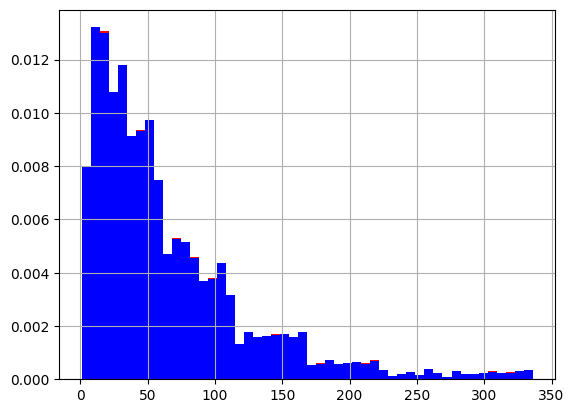

In [31]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)


df['training_hours'].hist(bins = 50 , ax = ax , density=True , color = 'red')
new_df['training_hours'].hist(bins = 50 , ax = ax , density=True , color = 'blue')
plt.show

we can see after removing rows distribution of data is still same across data
this proves data is mcar

In [34]:
temp = pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    new_df['enrolled_university'].value_counts()/len(new_df)
], axis = 1)
temp.columns = ['original','new']
temp

,original,new
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


since we can see in categorical colns too, we have almost same ratio as earlier
so data was mcar